In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
from torch import autograd as Grad

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.tri as mtri
import matplotlib


import ipywidgets as widgets
from IPython.display import display
import trimesh

import random
import math

import time
import os
import json

import copy



import open3d as o3d
print(o3d.__path__)
print('Using open3d version',o3d.__version__)
# Suppress Open3D warnings
o3d.utility.set_verbosity_level(o3d.utility.VerbosityLevel.Error)


from visuals import *

from bns_utils import *
from mesh_processing import *

import differential
import importlib
importlib.reload(differential)
from differential import *

two_pi = 2*torch.pi
diffmod = DifferentialModule()


['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Using open3d version 0.18.0
Implicit reps will use device: mps
Using device: mps
Implicit reps will use device: mps


/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/torch/nn/utils/weight_norm.py:134: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/Users/romywilliamson/Documents/BNS/bns/implicit_reps.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend 

In [2]:
#Load config file for the torus

with open("configs/surfaces/torus100.json", "r") as f:
    config_dict = json.load(f)


In [10]:
#Speed test using the vectorised BPS

import BPS
importlib.reload(BPS)
from BPS import BPS_fast
device='cpu'

# instantiate
bps = BPS_fast( config_dict, device=device)

bps.load_poly_coeffs('models/surfaces/torus7oct.pth')

time_start = time.time()
sample_dict = bps.compute_samples(num_samples=10)

x=sample_dict['uv'].detach().cpu()

precomputed_data = bps.precompute_data_from_samples(x)
time_end = time.time()

print('sampling and precomputation time:', time_end-time_start)

time_start = time.time()
result = bps.forward(precomputed_data).detach().cpu();
time_end = time.time()

print('fwd pass time:', time_end-time_start)



Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Initialising BPS on cpu
Assiging a halfedge to each vertex.
Preparing V_he for halfedge mesh
Prepared V_he for halfedge mesh.

Optimising V_he.
Finished optimising V_he.

base triangle verts torch.float32
Computing onering data.
Computing rotations.
sampling and precomputation time: 0.07785296440124512
fwd pass time: 0.0031099319458007812


In [ ]:
#Speed test using the old, no precomputation BS

import BNS
importlib.reload(BNS)
from BNS import BNS
device='mps'

# instantiate
bps = BNS(layer_sizes, from_file=True, coarse_patches_id=coarse_patches_id, posenc=posenc, angle_flag=angle_flag, overlap_param = overlap_param, degree=degree, global_scale=global_scale, blend_type=blend_type, device=device)

bps.load_poly_coeffs('models/surfaces/torus7oct.pth')

time_start = time.time()
sample_dict = bps.compute_samples(num_samples=10000)

x=sample_dict['uv']

time_end = time.time()

print('sampling time:', time_end-time_start)

time_start = time.time()
result = bps.forward(x).detach().cpu();
time_end = time.time()

print('fwd pass time:', time_end-time_start)

Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Assiging a halfedge to each vertex.
Preparing V_he for halfedge mesh
Prepared V_he for halfedge mesh.

Optimising V_he.
Finished optimising V_he.

base triangle verts torch.float32
Computing onering data.
Computing rotations.


dict_keys(['bary', 'coarse_embedding', 'uv'])

Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Assiging a halfedge to each vertex.
Preparing V_he for halfedge mesh
Prepared V_he for halfedge mesh.

Optimising V_he.
Finished optimising V_he.

base triangle verts torch.float32
Computing onering data.
Computing rotations.
sampling and precomputation time: 1.0307841300964355
fwd pass time: 0.15596294403076172


Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Assiging a halfedge to each vertex.
Preparing V_he for halfedge mesh
Prepared V_he for halfedge mesh.

Optimising V_he.
Finished optimising V_he.

base triangle verts torch.float32
Computing onering data.
Computing rotations.
sampling time: 0.03549003601074219
fwd pass time: 1.1276469230651855


onering_x torch.Size([100, 10000, 3, 2])
A torch.Size([50, 10, 3]) basis torch.Size([100, 10, 10000, 3])
A hat torch.Size([100, 3, 10, 3])
PXY torch.Size([100, 3, 10000, 3])
output torch.Size([100, 3, 10000, 3])


torch.Size([100, 3, 10000, 3])


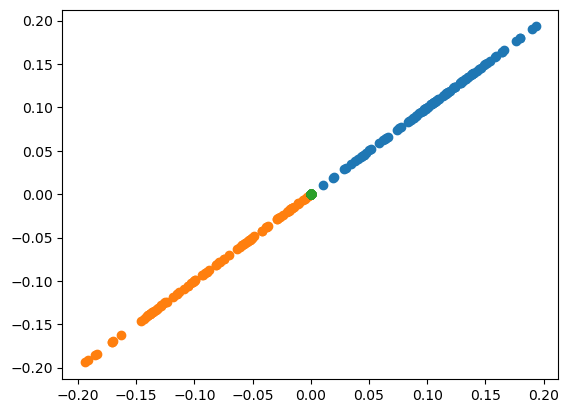

In [14]:
# generate training samples
training_sample_dict = bns.compute_samples(num_samples=1000000, avoid_corners=True)
coarse = training_sample_dict['coarse_embedding']


In [15]:
################# visualise BNS ##########################

import visuals
importlib.reload(visuals)
from visuals import *

import differential

importlib.reload(differential)
from differential import *

import mesh_processing
importlib.reload(mesh_processing)
from mesh_processing import *



bns_visualiser = BNS_visualiser(bns, mesh_res=6, use_original_mesh=False, test_flag='poly', just_onering=False, show_on_coarse=False, blend_type=blend_type)


#settings = [ 'default', 'unblended'] #blend, bary, curv, normals, default, angle, unblended

for i in [3]:
    settings = ['one-colour', 'normals', 'curv', 'default', 'unblended']
    settings = ['one-colour']
    bns_visualiser.compute_quantities(settings=settings, degree=i)
    bns_visualiser.show_bns(settings=settings)



###################################################################



device: cpu


/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/torch/nn/utils/weight_norm.py:134: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/Users/romywilliamson/Documents/BNS/bns/implicit_reps.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend 

TypeError: forward() missing 1 required positional argument: 'blend_weights'

In [ ]:
bns_visualiser.show_bns(settings=settings, vertex_id=0)

In [ ]:
############### initial training settings #####################

epoch=0

losses=[]
pos_losses=[]
normals_regs=[]
distortion_regs=[]
fractional_epochs=[]
eps = 1.0e-6

epochs=[]
times=[]
num_patches = bns.num_patches

loss=99999

optimizer = optim.Adam(bns.parameters(), lr=0.001)



In [ ]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output


import implicit_reps
import importlib
importlib.reload(implicit_reps)
from implicit_reps import *




##################### define training loop ###########################

def train_batch_loop(
    lr=0.01,
    batch_size=10000,
    min_loss=0.0005,
    normals_reg_coeff=0.0,
    distortion_reg_coeff=0.0,
    batch_print_rate=100,
    batch_plot_rate=10,
    epoch_print_rate=1,
    epoch_save_rate=1,
    epoch_plot_rate=1,
    plot=False,
    flag='poly',
    just_onering=False
):
    global optimizer, losses, pos_losses, normals_regs, times, epoch, loss, num_patches, eps, shape_id

    for g in optimizer.param_groups:
        g['lr'] = lr

    if just_onering==True:

        # If you want indices from a onering
        select_patch_indices = torch.tensor(
            bns.onerings[0]['triangles'], dtype=torch.long, device=bns.device
        )
    else:
        # If you want all triangle indices
        select_patch_indices = torch.arange(
            bns.F.shape[0], dtype=torch.long, device=bns.device
        )

    seqs = t_train.shape[0]
    total_points = t_train.shape[1]

    print(t_train.shape)

    #updated_target_train = target_train
    #print(updated_target_train.shape)

    while loss > min_loss:
        perm = torch.randperm(total_points)
        epoch_loss = 0.0

        for i in range(0, total_points, batch_size):
            batch_start = time.time()

            idx = perm[i:i + batch_size]
            batch_t = t_train[:, idx, :]

            optimizer.zero_grad()

            batch_t.requires_grad = True
            output_train, onering_x = bns(batch_t, select_patch_indices=select_patch_indices, return_onering_coords=True, test_flag=flag)
            check_for_nans(output_train, "output_train")


            selected_pts = output_train[select_patch_indices, :, :].to(device)


            print("output_train device:", output_train.device)
            print("select_patch_indices device:", getattr(select_patch_indices, "device", "not a tensor"))
            print("selected_pts device:", selected_pts.device)

            cur_sdf = sdf(selected_pts, shape_id)
            cur_udf = abs(cur_sdf)

            position_loss = cur_udf.mean()

            print('output, wrt', output_train.shape, batch_t.shape)


            if normals_reg_coeff > 0.0 or distortion_reg_coeff > 0.0:
                output_normals, jacobian = diffmod.compute_normals(out=output_train, wrt=batch_t, return_grad=True)
                #output_normals, jacobian = diffmod.compute_normals(out=output_train, wrt=onering_x, return_grad=True)
                
                check_for_nans(jacobian, "jacobian")
                check_for_nans(output_normals, "output_normals")


            if normals_reg_coeff > 0.0:
                

                grad_sdf = diffmod.gradient(out=cur_sdf.unsqueeze(-1), wrt=output_train).squeeze()
                check_for_nans(grad_sdf, "grad_sdf")

                normals_alignment = (output_normals * grad_sdf).sum(-1).mean()
                check_for_nans(normals_alignment, "normals_alignment")

                normals_reg = normals_reg_coeff * (-normals_alignment + 1.0)
                check_for_nans(normals_reg, "normals_reg")
            else:
                normals_reg = torch.tensor(0.0)


            if distortion_reg_coeff > 0.0:
                I_E, I_F, I_G = diffmod.compute_FFF(out=output_train, wrt=batch_t, jacobian=jacobian, normals=output_normals)
                trace = I_E + I_G
                det = I_E * I_G - I_F * I_F

                #distortion_reg = distortion_reg_coeff * ( trace / det.sqrt() ).mean()
                distortion_reg = distortion_reg_coeff * ( trace + trace / (det+eps) ).mean()

                
            else:
                distortion_reg = torch.tensor(0.0)    

            batch_loss = position_loss + normals_reg + distortion_reg
            check_for_nans(batch_loss, "batch_loss")

            batch_loss.backward()

            # Optional: clip gradients
            torch.nn.utils.clip_grad_norm_(bns.parameters(), max_norm=1.0)

            # Optional: check gradients for NaNs
            for name, param in bns.named_parameters():
                if param.grad is not None and torch.isnan(param.grad).any():
                    print(f"⚠️ NaNs in gradient of parameter: {name}")
                    raise ValueError(f"NaN gradient detected in {name}")

            optimizer.step()

            epoch_loss += batch_loss * batch_t.shape[1]

            batch_time = time.time() - batch_start

            times.append(batch_time)
            losses.append(batch_loss.detach().item())
            pos_losses.append(position_loss.detach().item())
            normals_regs.append(normals_reg.detach().item())
            distortion_regs.append(distortion_reg.detach().item())
            fractional_epochs.append(epoch + i / total_points)

            if i % batch_plot_rate == 0 and plot:
                try:
                    plt.close(fig)
                except:
                    pass
                    
                clear_output(wait=True)
                fig, axs = plt.subplots(2, 1, figsize=(10, 6))

                axs[0].plot(fractional_epochs, np.log10(losses), label='loss')
                axs[0].plot(fractional_epochs, np.log10(pos_losses), label='pos loss')
                if normals_reg_coeff > 0:
                    axs[0].plot(fractional_epochs, np.log10(normals_regs), label='normals reg')
                if distortion_reg_coeff > 0:
                    axs[0].plot(fractional_epochs, np.log10(distortion_regs), label='distortion reg')
                    
                axs[0].legend()
                axs[0].set_xlabel('Epoch')
                axs[0].set_ylabel('Log10 of Loss')
                axs[0].set_title('Log10 of Losses')

                axs[0].text(
                    0.8, 0.9, f"Batch Loss: {batch_loss.item():.8f}",
                    transform=axs[0].transAxes, ha='right', va='bottom',
                    fontsize=10, color='black',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
                )
                axs[0].text(
                    0.8, 0.8, f"Batch Pos. Loss: {position_loss.item():.8f}",
                    transform=axs[0].transAxes, ha='right', va='bottom',
                    fontsize=10, color='black',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
                )

                if normals_reg_coeff > 0:
                    axs[0].text(
                        0.8, 0.7, f"Batch Normals Reg.: {normals_reg.item():.8f}",
                        transform=axs[0].transAxes, ha='right', va='bottom',
                        fontsize=10, color='black',
                        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
                    )

                if distortion_reg_coeff > 0:
                    axs[0].text(
                        0.8, 0.6, f"Batch Distortion Reg.: {distortion_reg.item():.8f}",
                        transform=axs[0].transAxes, ha='right', va='bottom',
                        fontsize=10, color='black',
                        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
                    )

                axs[1].plot(fractional_epochs, times)
                axs[1].set_xlabel('Epoch')
                axs[1].set_title('Time per Batch')

                axs[1].text(
                    0.99, 0.90, f"Batch Time: {batch_time:.4f}s",
                    transform=axs[1].transAxes, ha='right', va='bottom',
                    fontsize=10, color='black',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
                )

                plt.tight_layout()
                display(fig)
                #plt.close(fig)

            if normals_reg_coeff > 0:
                print(f"Batch {i}, Loss: {batch_loss:.8f}, Pos. Loss: {position_loss:.8f}, "
                      f"Normals Reg: {(normals_reg_coeff * normals_reg):.8f}, Batch Time: {batch_time:.4f}s")
            else:
                print(f"Batch {i}, Loss: {batch_loss:.8f}, Pos. Loss: {position_loss:.8f}, Batch Time: {batch_time:.4f}s")

            print(f"mean UDF: {cur_udf.mean():.8f}")

            total_batch_time = time.time() - batch_start
            print(f"Time inc plotting: {total_batch_time:.4f}s")

            #clear_output(wait=True)

        loss = torch.tensor(epoch_loss / total_points)

        if epoch % epoch_print_rate == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.8f}")

        if epoch % epoch_save_rate == 0:
            #bns.save_mlps('models/temp.pth')
            bns.save_poly_coeffs('models/temp.pth')
            print('Saved checkpoint.')

        epoch += 1


In [ ]:
###### globals (sample points) needed for training 
t_train = training_sample_dict['uv']

In [ ]:
###### quick initial training
#train_batch_loop(lr=0.01, batch_size=1000, min_loss=0.0, normals_reg_coeff = 0.0, distortion_reg_coeff = 0.0, batch_plot_rate=1000, plot=True)

In [ ]:
###### quick initial training
#train_batch_loop(lr=0.01, batch_size=1000, min_loss=0.0, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.00001, batch_plot_rate=1000, plot=True)


In [ ]:
#train_batch_loop(lr=0.01, batch_size=1000, min_loss=0.0, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.00001, batch_plot_rate=1000, plot=True)

In [ ]:
####### slower finetuning
#train_batch_loop(lr=0.001, batch_size=1000, min_loss=0.0, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.00001, batch_plot_rate=10, plot=True)
#train_batch_loop(lr=0.001, batch_size=1000, min_loss=0.0, normals_reg_coeff = 0.0, batch_plot_rate=1, plot=True)


In [ ]:
#train_batch_loop(lr=1.0, batch_size=1000, min_loss=0.0, normals_reg_coeff = 0.0, distortion_reg_coeff = 0.0, batch_plot_rate=10, plot=True)

In [ ]:
#train_batch_loop(lr=0.01, batch_size=1000, min_loss=0.0, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.00001, batch_plot_rate=10, plot=True)

In [ ]:
#train_batch_loop(lr=0.01, batch_size=1000, min_loss=0.0, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.00001, batch_plot_rate=10, plot=True)

In [ ]:
train_batch_loop(lr=0.001, batch_size=1000, min_loss=0.0, normals_reg_coeff = 0.0, distortion_reg_coeff = 0.0, batch_plot_rate=10, plot=True)

In [ ]:
bns.poly_coeffs

In [ ]:
######### save model ############
ans = input('Would you like to save the model? y/n')
if ans=='y':
    filename = input('What filename would you like to save it as (no extension)?')
    bns.save_poly_coeffs('models/'+filename+'.pth')
    print('Saved model parameters as '+filename+'.pth')


In [ ]:
######## zero out polynomial coeffs #########
#bns.set_poly_coeffs_to_zero(degree=4)

In [ ]:
######### load model ############

#bns.load_poly_coeffs('models/sphere_normals_and_dist_reg_0209.pth')

In [ ]:
#bns.save_poly_coeffs('models/sphere100_poly_no_edge.pth')

In [ ]:
################ visualise bns ##################


# If you want indices from onerings
select_patch_indices = torch.tensor(
    bns.onerings[0]['triangles'], dtype=torch.long, device=bns.device
)



# If you want all triangle indices
select_patch_indices = torch.arange(
    bns.F.shape[0], dtype=torch.long, device=bns.device
)



import visuals
import importlib
importlib.reload(visuals)
from visuals import *

bns_visualiser = BNS_visualiser(bns, mesh_res=7, test_flag='poly', blend_type=blend_type, just_onering=False, use_original_mesh=False,
                               show_on_coarse=False)

      

settings = ['default','normals', 'angle', 'blend', 'bary', 'curv', 'unblended']
settings = ['default', 'normals']
#settings = ['default', 'one-colour', 'angle']
#settings = ['elastic_energy']
#settings = ['discrete_blend']

#settings = ['default', 'one-colour', 'unblended']

#settings = ['normals']

bns_visualiser.compute_quantities(settings=settings)


In [ ]:
bns_visualiser.show_bns(settings=settings)

In [ ]:
import visuals
importlib.reload(visuals)
from visuals import *




In [ ]:
bns.poly_coeffs

In [ ]:
with torch.no_grad():
    for i in range(52):
        bns.poly_coeffs[i][0,:] = bns.poly_coeffs[i][0,:]*0

In [ ]:
############# Translating a Single Coarse Vertex ############
bns.reset()


T = torch.zeros_like(bns.V)
T[0,:] = torch.tensor([-0.1, +0.1, 0.0 ])

bns.V = bns.V + T

bns.compute_fixed_rotations()

bns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False)

bns_visualiser.compute_quantities()
bns_visualiser.show_bns()
bns.reset()
bns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False)
bns_visualiser.compute_quantities()
bns_visualiser.show_bns()

In [ ]:
############# Perturbing Vertices ############
bns.reset()


T = torch.zeros_like(bns.V)
T += 0.01*torch.randn(bns.V.shape)

bns.V = bns.V + T

bns.compute_fixed_rotations()

bns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False)

bns_visualiser.compute_quantities()
bns_visualiser.show_bns()
bns.reset()
bns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False)
bns_visualiser.compute_quantities()
bns_visualiser.show_bns()

In [ ]:
import visuals
importlib.reload(visuals)
from visuals import *

import implicit_reps
import importlib
importlib.reload(implicit_reps)
from implicit_reps import *

bns_visualiser = BNS_visualiser(bns, mesh_res=2, test_flag='poly', blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False)

bns_visualiser.show_implicit_error_on_pcd(shape_id, num_samples=10000)

In [ ]:
bns.poly_coeffs